In [1]:
import pandas as pd

url = "https://www.sharkattackfile.net/spreadsheets/GSAF5.xls"

df = pd.read_excel(url)

df = df.drop(columns= ["Time", "Unnamed: 21", "Unnamed: 22", "Name", "href", "Case Number", "Case Number.1", "original order", "href formula", "pdf", "Source", "Species ", "Injury", "Sex"])

percentage_missing = (df.isnull().sum() / len(df) * 100).round(2)

df

,Date,Year,Type,Country,State,Location,Activity,Age,Fatal Y/N
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,39,N
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,?,N
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,?,N
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,50's,N
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,55,Y
...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,NaN,Y
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,NaN,Y
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,NaN,Y
7080,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,NaN,Y


In [11]:
df.drop_duplicates(inplace=True)

df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())


,Date,Year,Type,Country,State,Location,Activity,Age,Fatal Y/N


In [75]:
df[df["Country"].str.contains("ustral", case=False, na=False)]["Country"].value_counts()

df["Country"] = df["Country"].str.strip().str.lower()

df["Country"].value_counts()

df["Fatal Y/N"] = df["Fatal Y/N"].str.strip().str.upper()

df["Fatal Y/N"] = df["Fatal Y/N"].replace({"Y X 2":"Y"})

df = df[df["Fatal Y/N"].isin(["Y", "N"])]

df

,Date,Year,Type,Country,State,Location,Activity,Age,Fatal Y/N
0,18th March,2026.0,Unprovoked,usa,California,Big River Beach Mendocino County,Surfing,39,N
1,14th March,2026.0,Unprovoked,australia,Western Australia,Exmouth,Swimming,?,N
2,10th March,2026.0,Unprovoked,australia,Western Australia,Exmouth,Wing Foiling,?,N
3,5th March,2026.0,Unprovoked,australia,Queensland,Lady Elliott Island,Snorkeling,50's,N
4,22nd February,2026.0,Unprovoked,new caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,55,Y
...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,australia,Western Australia,Roebuck Bay,Diving,NaN,Y
7078,Before 1903,0.0,Unprovoked,australia,Western Australia,NaN,Pearl diving,NaN,Y
7079,1900-1905,0.0,Unprovoked,usa,North Carolina,Ocracoke Inlet,Swimming,NaN,Y
7080,1883-1889,0.0,Unprovoked,panama,NaN,"Panama Bay 8ºN, 79ºW",NaN,NaN,Y


In [25]:
df["Fatal Y/N"].value_counts()

Fatal Y/N
N    4926
Y    1483
Name: count, dtype: int64

In [33]:
h1_df = df[df["Country"] == "australia"]

(h1_df["Year"] == 0).sum()

np.int64(14)

In [37]:
h1_df = h1_df[h1_df["Year"] >= 1788]


1788.0

In [43]:
h1_df["Decade"] = (h1_df["Year"] // 10 * 10).astype("Int64")

In [45]:
h1_df.groupby("Decade")

h1_df.groupby("Decade").size()



Decade
1780      1
1790      1
1800      3
1820      2
1830      4
1840     11
1850      7
1860     11
1870     27
1880     32
1890     21
1900     28
1910     45
1920     86
1930    118
1940     67
1950     88
1960    121
1970     55
1980     39
1990     61
2000    155
2010    242
2020    140
dtype: int64

In [76]:
h1_df["Is_Fatal"] = (h1_df["Fatal Y/N"] == "Y").astype(int)

In [58]:
summary = h1_df.groupby("Decade").agg(total_incidents=("Is_Fatal", "size"), fatal_incidents=("Is_Fatal", sum))


summary["fatal_share"] = ((summary["fatal_incidents"] / summary["total_incidents"]) * 100).round(1)

summary


/var/folders/5r/56m82rjn5cqdmz3b771c5t8c0000gn/T/ipykernel_49387/2568085466.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  summary = h1_df.groupby("Decade").agg(total_incidents=("Is_Fatal", "size"), fatal_incidents=("Is_Fatal", sum))


,total_incidents,fatal_incidents,fatal_share
Decade,,,
1780,1,0,0.0
1790,1,1,100.0
1800,3,0,0.0
1820,2,1,50.0
1830,4,2,50.0
1840,11,6,54.5
1850,7,6,85.7
1860,11,4,36.4
1870,27,10,37.0


/var/folders/5r/56m82rjn5cqdmz3b771c5t8c0000gn/T/ipykernel_49387/2543836421.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h1_data["non_fatal"] = (h1_data["total_incidents"] - h1_data["fatal_incidents"]).copy()


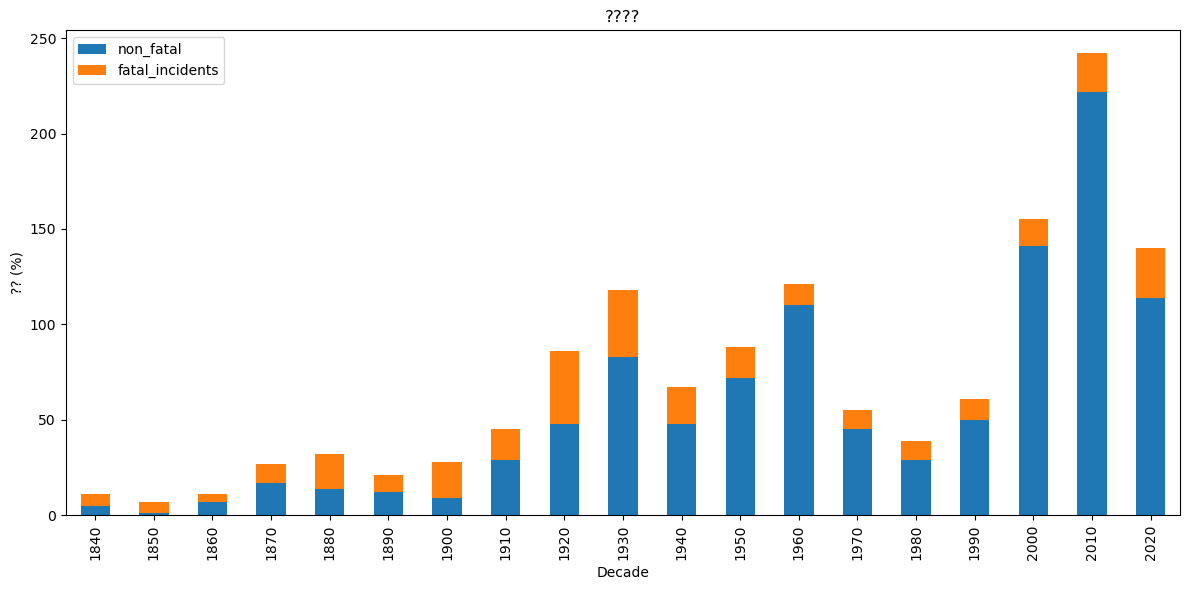

In [82]:


h1_data = summary.loc[1840:]

h1_data["non_fatal"] = (h1_data["total_incidents"] - h1_data["fatal_incidents"]).copy()

import matplotlib.pyplot as plt

h1_data[["non_fatal", "fatal_incidents"]].plot(kind="bar", stacked=True, figsize=(12, 6), title="????", ylabel= "??"" (%)")

plt.tight_layout()

plt.show()

**H1 — Fatal shark incidents in Australia over time**

**Findings:**

Fatal incidents in Australia have not risen dramatically over time in absolute terms.

Total incidents, however, have exploded — from 86 in the 1920s to 242 in the 2010s, nearly triple.
As a result, the fatality share has dropped substantially. In the early 1900s, a high proportion of recorded encounters were fatal; in recent decades, it's much lower.


**Conclusions:**

H1 is partially supported but misleading in its framing. 

Raw fatal counts are slightly elevated in recent decades compared to the late 1900s, but they're not at a historical high — the 1920s and 1930s were worse.
**More importantly, the probability of dying given a shark encounter has fallen substantially over the last century.**

The real story is more exposure, not deadlier sharks. More people in the water, better beach monitoring, better medical response, faster rescue times — all of which mean more encounters but fewer deaths per encounter.


**Recommendations for insurers:**

- Don't price Australian shark risk like it's getting deadlier — it isn't. Each incident is less severe than it used to be.
- Expect more claims, but not worse ones. This is about volume, not catastrophe. Reserves, underwriting, and pricing should reflect that.
- Lean on recent decades when setting prices. Fatality rates from the 1920s–30s don't reflect today's risk.
- Model both sides together: more people in the water means more incidents, even as each one becomes more survivable. Total claim costs can still rise.


**Caveats:**

- The earliest decades (1780s–1860s) had very few incidents, so they weren't used to draw conclusions about fatality rates.
- The 2020s isn't over yet, so fatal incidents will grow before the decade ends.
- Old records are probably incomplete
- This only covers Australia.